# NFI / NIR Metrics and fsQCA Calibration

Computes the **Net Flexibility Incentive (NFI)** and **Net Incentive Ratio (NIR)** from the
solver output CSVs, and exports the **fsQCA-ready condition/outcome table** for the Germany
case set (Archetypes 3–8 × 7 DSOs = 42 cases). Step 5 builds the **case-level** dataset;
Step 8 aggregates it into a **configuration-level** truth table (sufficiency diagnostics).
Step 11 writes every CSV artefact used in the thesis appendix (after robustness checks).

## Metric definitions (Chapter 4, Section 4.3)

| Metric | Formula | Interpretation |
|---|---|---|
| **NFI_eur** | `TCoE_noflex − TCoE_tcoeflex` | Absolute annual bill saving from full-stack opt (€/yr); always defined |
| **NIR** | `(TCoE_noflex − TCoE_dtflex) / (TCoE_noflex − TCoE_tcoeflex)` | Fraction of full-stack saving captured by spot-only opt |

NIR = 1 → perfect alignment; NIR < 1 → dilution. Undefined for A1/A2 (no flex DOF).

## fsQCA design (Chapter 4, Section 4.8)

| Condition | Source | Type | Calibration |
|---|---|---|---|
| `BSS` | archetype ∈ {3,8} | Crisp binary | — |
| `HP` | archetype ∈ {4,6,8} | Crisp binary | — |
| `EV` | archetype ∈ {5,7,8} | Crisp binary | — |
| `MOD3_SIGNAL` | HT − NT spread (ct/kWh) from DSO tariff | Fuzzy | 25th / 50th / 75th percentile anchors across the 7 DSOs |
| `DSO_VOL_LEVEL` | Arbeitspreis (ct/kWh) from DSO tariff | Fuzzy | 25th / 50th / 75th percentile anchors across the 7 DSOs |
| **LOW_NIR** (outcome) | NIR with inverted direction | Fuzzy | 25th / 50th / 75th percentile anchors across the 42 flexible cases |

All fuzzy conditions use harmonised 25/50/75 anchors (Ragin 2008, Chapter 4). Consistency thresholds
follow Schneider & Wagemann (2012, Chapter 5): sufficiency ≥ 0.75, necessity ≥ 0.90.

**Inputs**: `outputs/results_*.csv`, `inputs/dso_tariffs_residential_2026.csv`
**Outputs**: `nfi_nir_germany_2026.csv`, `fsqca_conditions_germany_2026.csv`,
`fsqca_calibration_anchors_germany_2026.csv`, `fsqca_truth_table_germany_2026.csv`,
`fsqca_necessity_screen_germany_2026.csv` (all written in Step 11).

**Thesis reference**: Chapter 4, Section 4.8; Chapter 5, Section 5.3; Appendix D.


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError('Repo root not found')

REPO_ROOT  = find_repo_root()
INPUTS     = REPO_ROOT / 'inputs'
ANALYSIS   = Path('__file__').resolve().parent  # save outputs next to this notebook
print(f'Repo root: {REPO_ROOT}')


Repo root: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load and consolidate all solver outputs

In [3]:
# All eight archetype result files; each contains rows for 3 strategies × 7 DSOs
csv_files = sorted((REPO_ROOT / 'outputs').glob('results_*.csv'))
print('CSV files found:', [f.name for f in csv_files])

raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'Total rows loaded: {len(raw)}')
print('Archetypes:', sorted(raw['household_archetype'].unique()))
print('DSOs:      ', sorted(raw['dso_id'].unique()))
print('Strategies:', sorted(raw['strategy'].unique()))


CSV files found: ['results_base_2026.csv', 'results_base_ev_2026.csv', 'results_base_hp_2026.csv', 'results_base_pv_2026.csv', 'results_base_pv_bss_2026.csv', 'results_base_pv_bss_hp_ev_2026.csv', 'results_base_pv_ev_2026.csv', 'results_base_pv_hp_2026.csv']
Total rows loaded: 168
Archetypes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
DSOs:       ['Bayernwerk', 'E.DIS', 'MITNETZ STROM', 'Netze BW', 'SH Netz', 'Stromnetz Berlin', 'Westnetz']
Strategies: ['dt_flex', 'no_flex', 'tcoe_flex']


## Step 2 — Pivot to wide format and compute NFI / NIR

Each (archetype, DSO) pair needs TCoE for all three strategies on one row before we can compute
the ratios. We pivot on strategy, then apply the formulas.

In [4]:
# Pivot: one row per (archetype, DSO), three TCoE columns
wide = raw.pivot_table(
    index=['household_archetype', 'dso_id'],
    columns='strategy',
    values='total_tcoe_eur',
    aggfunc='first'
).reset_index()
wide.columns.name = None

# Rename for clarity
wide = wide.rename(columns={
    'no_flex'  : 'TCoE_noflex',
    'dt_flex'  : 'TCoE_dtflex',
    'tcoe_flex': 'TCoE_tcoeflex',
})

# NFI_eur: absolute annual saving from full-stack optimisation vs. no-flex [EUR/yr].
wide['NFI_eur'] = (wide['TCoE_noflex'] - wide['TCoE_tcoeflex']).round(2)

# Absolute dt_flex saving (EUR/yr)
wide['saving_dtflex_eur'] = (wide['TCoE_noflex'] - wide['TCoE_dtflex']).round(2)

# NIR: fraction of full-stack saving captured by spot-only DT-flex
denom = wide['TCoE_noflex'] - wide['TCoE_tcoeflex']
no_flex_archetypes = [1, 2]   # A1 (Base) and A2 (Base+PV) have no dispatch DOF
wide['NIR'] = np.where(
    wide['household_archetype'].isin(no_flex_archetypes) | (denom.abs() < 1e-6),
    np.nan,
    ((wide['TCoE_noflex'] - wide['TCoE_dtflex']) / denom).round(4)
)

print(wide[['household_archetype','dso_id','TCoE_noflex','TCoE_dtflex','TCoE_tcoeflex',
            'NFI_eur','NIR']].to_string(index=False))


 household_archetype           dso_id  TCoE_noflex  TCoE_dtflex  TCoE_tcoeflex  NFI_eur    NIR
                   1       Bayernwerk      1224.96      1224.96        1224.96     0.00    NaN
                   1            E.DIS      1239.06      1239.06        1239.06     0.00    NaN
                   1    MITNETZ STROM      1279.70      1279.70        1279.70     0.00    NaN
                   1         Netze BW      1360.26      1360.26        1360.26     0.00    NaN
                   1          SH Netz      1310.58      1310.58        1310.58     0.00    NaN
                   1 Stromnetz Berlin      1294.11      1294.11        1294.11     0.00    NaN
                   1         Westnetz      1460.82      1460.82        1460.82     0.00    NaN
                   2       Bayernwerk       267.22       267.22         267.22     0.00    NaN
                   2            E.DIS       264.94       264.94         264.94     0.00    NaN
                   2    MITNETZ STROM       287.23

## Step 3 — Summary statistics

Quick sanity check: NFI/NIR distribution by archetype (averaged across DSOs).

In [5]:
summary = (
    wide.groupby('household_archetype')
    [['NFI_eur','NIR']]
    .agg(['mean','min','max'])
    .round(3)
)
print('NFI / NIR summary by archetype (mean | min | max across 7 DSOs):')
display(summary)

nir_flex = wide[wide['household_archetype'].isin(range(3,9))]['NIR'].dropna()
q25, q50, q75 = nir_flex.quantile([0.25, 0.50, 0.75]).values
print(f'\nNIR distribution (N=42 flexible cases): '
      f'p25={q25:.3f} | median={q50:.3f} | p75={q75:.3f} | '
      f'min={nir_flex.min():.3f} | max={nir_flex.max():.3f}')


NFI / NIR summary by archetype (mean | min | max across 7 DSOs):


NFI_eur                      NIR              
                         mean      min      max   mean    min    max
household_archetype                                                 
1                       0.000     0.00     0.00    NaN    NaN    NaN
2                       0.000     0.00     0.00    NaN    NaN    NaN
3                     176.853   176.18   177.44  0.468  0.335  0.566
4                     340.639   193.10   517.51  0.465  0.276  0.767
5                     553.689   493.22   666.85  0.793  0.652  0.884
6                     568.003   402.59   755.61  0.294  0.214  0.402
7                     763.610   663.64   885.45  0.578  0.495  0.661
8                    1322.469  1059.15  1619.25  0.491  0.377  0.623


NIR distribution (N=42 flexible cases): p25=0.405 | median=0.493 | p75=0.595 | min=0.214 | max=0.884


## Step 4 — fsQCA condition construction and calibration

**Direct logistic calibration** (Ragin 2008, Ch. 5) maps each raw score to a [0,1] fuzzy
membership via a log-odds interpolation between three empirical anchors:
`full_out` (maps to 0.05), `crossover` (maps to 0.5), and `full_in` (maps to 0.95).

First map raw $x$ to log-odds $L(x)$ piecewise so that $L(\mathrm{crossover})=0$,
$L(\mathrm{full\_in})=\ln 19$, and $L(\mathrm{full\_out})=-\ln 19$. This is the same
construction as Section 4.8.3 of the thesis (`full_in` / `crossover` / `full_out` here are
$x_{\mathrm{in}}$ / $x_{0.5}$ / $x_{\mathrm{out}}$ there):

```
L(x) = ln(19)/(full_in − crossover) · (x − crossover)   if x ≥ crossover
     = ln(19)/(crossover − full_out) · (x − crossover)   otherwise

μ(x) = exp(L) / (1 + exp(L))
```

The helper `calibrate_fuzzy` stores the two slope prefactors as `b_above` and `b_below`; they
are exactly the fractions above — useful in code, not a different formula.

Anchors 0.95 / 0.05 correspond to log-odds $\pm\ln 19 \approx \pm 2.94$
(Ragin rounds to $\pm 3.0$ in his worked example).

For **LOW_NIR**, direction matches Section 4.8.3 (low raw NIR $\rightarrow$ high membership).
The notebook calibrates `-NIR` with negated anchors; that is equivalent to flipping the sign of
the deviations in $L(x)$ as in the thesis.

**Anchor choice.** Harmonised 25th / 50th / 75th percentile anchors are used for every fuzzy
condition (the two DSO conditions over the 7 DSOs, and LOW_NIR over the 42 flexible cases).


In [6]:
def calibrate_fuzzy(x, full_in, crossover, full_out):
    """Piecewise direct logistic calibration (Ragin 2008, Ch. 5).

    Two slopes ensure both outer anchors are exactly respected:
      full_in  → 0.95  (log-odds +ln19)
      crossover → 0.50  (log-odds  0)
      full_out → 0.05  (log-odds −ln19)

    Direction: higher x → higher membership (reverse sign outside for inverted conditions).
    """
    x = np.asarray(x, dtype=float)
    b_above = np.log(19) / (full_in  - crossover)
    b_below = np.log(19) / (crossover - full_out)
    log_odds = np.where(x >= crossover,
                        b_above * (x - crossover),
                        b_below * (x - crossover))
    return np.exp(log_odds) / (1.0 + np.exp(log_odds))


# -- Load DSO tariff parameters -----------------------------------------------
dso = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
dso = dso.rename(columns={'DSO': 'dso_id'})

# MOD3_SIGNAL: §14a Modul 3 HT-NT spread [ct/kWh]; larger spread -> stronger time signal
dso['MOD3_SIGNAL_raw'] = dso['HT_ct_kWh'] - dso['NT_ct_kWh']

# DSO_VOL_LEVEL: standard Arbeitspreis [ct/kWh]; higher rate -> more volumetric dilution
dso['DSO_VOL_LEVEL_raw'] = dso['Arbeitspreis_ct_kWh']

# Harmonised 25/50/75 percentile anchors derived from the empirical DSO distribution (N=7)
for col in ['MOD3_SIGNAL_raw', 'DSO_VOL_LEVEL_raw']:
    vals = dso[col]
    q25, q50, q75 = vals.quantile([0.25, 0.50, 0.75]).values
    print(f'{col}: p25={q25:.3f} | p50={q50:.3f} | p75={q75:.3f}')

# Anchors for MOD3_SIGNAL (high spread -> higher membership)
mod3_p25, mod3_p50, mod3_p75 = dso['MOD3_SIGNAL_raw'].quantile([0.25, 0.50, 0.75]).values
dso['MOD3_SIGNAL'] = calibrate_fuzzy(
    dso['MOD3_SIGNAL_raw'], full_in=mod3_p75, crossover=mod3_p50, full_out=mod3_p25
).round(4)

# Anchors for DSO_VOL_LEVEL (high Arbeitspreis -> higher membership)
vol_p25, vol_p50, vol_p75 = dso['DSO_VOL_LEVEL_raw'].quantile([0.25, 0.50, 0.75]).values
dso['DSO_VOL_LEVEL'] = calibrate_fuzzy(
    dso['DSO_VOL_LEVEL_raw'], full_in=vol_p75, crossover=vol_p50, full_out=vol_p25
).round(4)

print('\nDSO condition scores:')
print(dso[['dso_id','Arbeitspreis_ct_kWh','MOD3_SIGNAL_raw',
           'MOD3_SIGNAL','DSO_VOL_LEVEL']].to_string(index=False))


MOD3_SIGNAL_raw: p25=8.140 | p50=8.560 | p75=11.630
DSO_VOL_LEVEL_raw: p25=5.890 | p50=6.400 | p75=7.515

DSO condition scores:
          dso_id  Arbeitspreis_ct_kWh  MOD3_SIGNAL_raw  MOD3_SIGNAL  DSO_VOL_LEVEL
        Westnetz                 9.53            14.70       0.9972         0.9997
      Bayernwerk                 4.72             8.56       0.5000         0.0001
           E.DIS                 5.47             8.25       0.1022         0.0046
        Netze BW                 7.57             8.03       0.0238         0.9565
Stromnetz Berlin                 7.46            11.33       0.9344         0.9426
         SH Netz                 6.40             7.68       0.0021         0.5000
   MITNETZ STROM                 6.31            11.93       0.9620         0.3729


## Step 5 — Case-level fsQCA dataset (N = 42)

One row per **case** (archetype–DSO pair): crisp device conditions, fuzzy DSO conditions, calibrated
`LOW_NIR`, and billing metrics. This is the input matrix for fsQCA, *not* the truth table.
The truth table (one row per *configuration*, with *n* cases and consistency scores) is built in Step 8.


In [7]:
# ── Binary device conditions (from archetype number) ─────────────────────────
# Only include flexible archetypes (3–8); A1 and A2 have no NIR
fsqca_rows = wide[wide['household_archetype'].isin(range(3, 9))].copy()

fsqca_rows['BSS'] = fsqca_rows['household_archetype'].isin([3, 8]).astype(int)
fsqca_rows['HP']  = fsqca_rows['household_archetype'].isin([4, 6, 8]).astype(int)
fsqca_rows['EV']  = fsqca_rows['household_archetype'].isin([5, 7, 8]).astype(int)

# Join DSO-level conditions
fsqca_rows = fsqca_rows.merge(
    dso[['dso_id','Arbeitspreis_ct_kWh','MOD3_SIGNAL_raw','MOD3_SIGNAL','DSO_VOL_LEVEL']],
    on='dso_id', how='left'
)

# ── Calibrate LOW_NIR outcome ─────────────────────────────────────────────────
# Direction inverted: lower NIR → higher LOW_NIR membership
# Anchors from NIR distribution (Chapter 4, Section 4.8 / Appendix D)
nir_vals = fsqca_rows['NIR'].dropna()
nir_p25, nir_p50, nir_p75 = nir_vals.quantile([0.25, 0.50, 0.75]).values
print(f'NIR calibration anchors: full_in={nir_p25:.4f} | crossover={nir_p50:.4f} | full_out={nir_p75:.4f}')

# For inverted direction (low NIR → high LOW_NIR), pass negative values
fsqca_rows['LOW_NIR'] = calibrate_fuzzy(
    -fsqca_rows['NIR'],              # invert: low NIR becomes large
    full_in=-nir_p25,                # full member at low NIR (= high -NIR)
    crossover=-nir_p50,
    full_out=-nir_p75
).round(4)

# ── Case identifier ───────────────────────────────────────────────────────────
fsqca_rows['case_id'] = 'A' + fsqca_rows['household_archetype'].astype(str) + '_' + fsqca_rows['dso_id']

cols_out = ['case_id','household_archetype','dso_id',
            'BSS','HP','EV','MOD3_SIGNAL','DSO_VOL_LEVEL',
            'NIR','LOW_NIR',
            'NFI_eur','TCoE_noflex','TCoE_dtflex','TCoE_tcoeflex']
fsqca_out = fsqca_rows[cols_out].reset_index(drop=True)

print(f'\nCase-level fsQCA dataset: {len(fsqca_out)} rows (expected 42)')
display(fsqca_out.sort_values(['household_archetype','dso_id']))


NIR calibration anchors: full_in=0.4048 | crossover=0.4927 | full_out=0.5951

Case-level fsQCA dataset: 42 rows (expected 42)


,case_id,household_archetype,dso_id,BSS,HP,EV,MOD3_SIGNAL,DSO_VOL_LEVEL,NIR,LOW_NIR,NFI_eur,TCoE_noflex,TCoE_dtflex,TCoE_tcoeflex
0,A3_Bayernwerk,3,Bayernwerk,1,0,0,0.5000,0.0001,0.5659,0.1085,177.44,11.58,-88.83,-165.86
1,A3_E.DIS,3,E.DIS,1,0,0,0.1022,0.0046,0.5303,0.2531,177.21,-6.84,-100.81,-184.05
2,A3_MITNETZ STROM,3,MITNETZ STROM,1,0,0,0.9620,0.3729,0.4903,0.5197,176.95,-2.64,-89.39,-179.59
3,A3_Netze BW,3,Netze BW,1,0,0,0.0238,0.9565,0.4299,0.8913,176.62,23.28,-52.65,-153.34
4,A3_SH Netz,3,SH Netz,1,0,0,0.0021,0.5000,0.4860,0.5555,176.93,24.34,-61.64,-152.59
5,A3_Stromnetz Berlin,3,Stromnetz Berlin,1,0,0,0.9344,0.9426,0.4352,0.8728,176.64,-38.11,-114.98,-214.75
6,A3_Westnetz,3,Westnetz,1,0,0,0.9972,0.9997,0.3353,0.9949,176.18,38.82,-20.26,-137.36
7,A4_Bayernwerk,4,Bayernwerk,0,1,0,0.5000,0.0001,0.7673,0.0004,193.10,2270.39,2122.23,2077.29
8,A4_E.DIS,4,E.DIS,0,1,0,0.1022,0.0046,0.4441,0.8359,331.70,2342.42,2195.12,2010.72
9,A4_MITNETZ STROM,4,MITNETZ STROM,0,1,0,0.9620,0.3729,0.4290,0.8942,341.11,2420.54,2274.21,2079.43


## Step 6 — Visualizations

Calibration curves and diagnostic plots for the fuzzy conditions and outcome.

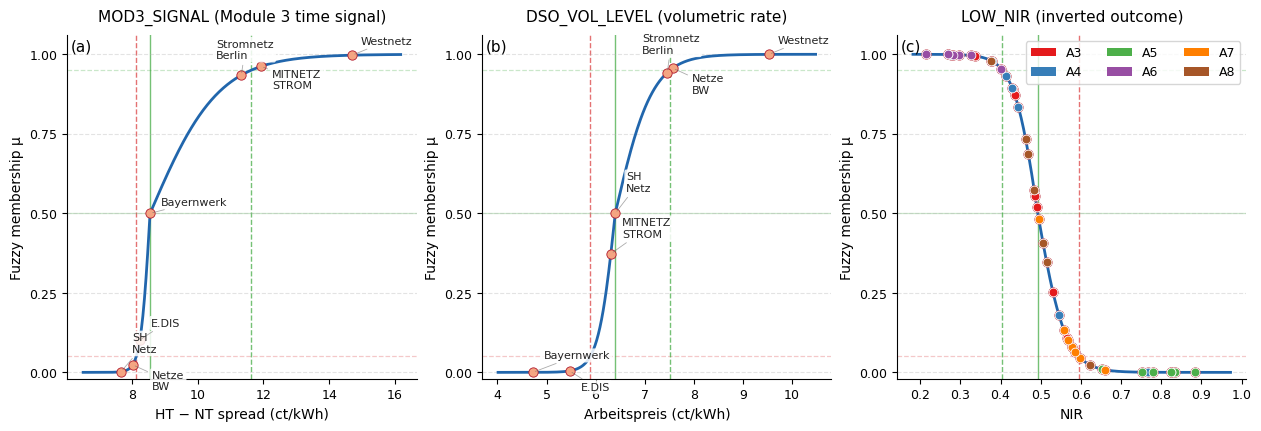

Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/../02_Obsidian_Vault/03_Drafts/assets/fig_fsqca_calibration_curves_germany_2026.png


In [8]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# -- thesis figure rc (shared across notebooks) --
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ── Path configuration (same convention as other notebooks) ───────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT = find_repo_root()
OUT_FIG = REPO_ROOT / '..' / '02_Obsidian_Vault' / '03_Drafts' / 'assets' / 'fig_fsqca_calibration_curves_germany_2026.png'


def _draw_panel(ax, raw_vals, full_in, crossover, full_out, *,
                xlabel, title, inverted=False, labels=None, panel_tag=None,
                label_offsets=None):
    raw_vals = np.asarray(raw_vals, dtype=float)

    # Smooth curve support
    lo = min(np.nanmin(raw_vals), full_out) * 0.85
    hi = max(np.nanmax(raw_vals), full_in)  * 1.10
    xs = np.linspace(lo, hi, 400)

    if inverted:
        ys = calibrate_fuzzy(-xs, full_in=-full_in, crossover=-crossover, full_out=-full_out)
    else:
        ys = calibrate_fuzzy(xs, full_in=full_in, crossover=crossover, full_out=full_out)

    ax.plot(xs, ys, color='#2166ac', lw=2.0, zorder=2)

    # Anchors (vertical) + membership reference lines (horizontal)
    for xv, yv, ls, col in [
        (full_out,  0.05, '--', 'tab:red'),
        (crossover, 0.50, '-',  'tab:green'),
        (full_in,   0.95, '--', 'tab:green'),
    ]:
        ax.axvline(xv, color=col, lw=1.0, ls=ls, alpha=0.65, zorder=1)
        ax.axhline(yv, color=col, lw=0.9, ls=ls, alpha=0.25, zorder=1)

    # Data points
    mask = ~np.isnan(raw_vals)
    raw_plot = raw_vals[mask]

    if inverted:
        mus = calibrate_fuzzy(-raw_plot,
                              full_in=-full_in, crossover=-crossover, full_out=-full_out)
    else:
        mus = calibrate_fuzzy(raw_plot, full_in=full_in, crossover=crossover, full_out=full_out)

    ax.scatter(raw_plot, mus, color='#f4a582', edgecolors='#b2182b',
               s=45, linewidths=0.6, zorder=3)

    if labels is not None:
        # Labels: prefer manual offsets (stable, no overlap with titles), else gentle alternation
        labels = list(labels)
        labels_plot = [lbl for lbl, keep in zip(labels, mask) if keep]
        label_offsets = label_offsets or {}

        order = np.argsort(raw_plot)
        offsets = [(8, 6), (8, -8), (12, 10), (12, -12), (16, 14), (16, -16)]

        for j, idx in enumerate(order):
            lbl = labels_plot[idx]
            if not lbl:
                continue
            x_pt = raw_plot[idx]
            y_pt = mus[idx]

            dx, dy = label_offsets.get(str(lbl), offsets[j % len(offsets)])

            ax.annotate(
                str(lbl),
                (x_pt, y_pt),
                textcoords='offset points',
                xytext=(dx, dy),
                fontsize=8,
                color='#222222',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.85, edgecolor='none'),
                arrowprops=dict(arrowstyle='-', color='#666666', lw=0.6, alpha=0.55),
                clip_on=False,
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fuzzy membership μ')
    ax.set_title(title, pad=10)
    ax.set_ylim(-0.02, 1.06)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

    if panel_tag:
        ax.text(0.01, 0.99, panel_tag, transform=ax.transAxes,
                ha='left', va='top', fontsize=11, fontweight='normal')


fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), constrained_layout=True)

# (a) MOD3_SIGNAL (DSO-level)
dso_labels = dso['dso_id'].str.replace(' ', '\n').values

# Manual label offsets (points) to avoid title/anchor overlaps
label_offsets_mod3 = {
    'Westnetz': (6, 8),
    'Stromnetz\nBerlin': (-18, 12),
    'MITNETZ\nSTROM': (8, -16),
    'Bayernwerk': (8, 6),
    'E.DIS': (8, 10),
    'SH\nNetz': (8, 14),
    'Netze\nBW': (14, -18),
}

_draw_panel(
    axes[0],
    raw_vals=dso['MOD3_SIGNAL_raw'].values,
    labels=dso_labels,
    full_in=mod3_p75, crossover=mod3_p50, full_out=mod3_p25,
    xlabel='HT − NT spread (ct/kWh)',
    title='MOD3_SIGNAL (Module 3 time signal)',
    panel_tag='(a)',
    label_offsets=label_offsets_mod3,
)

# (b) DSO_VOL_LEVEL (DSO-level)
label_offsets_vol = {
    'Westnetz': (6, 8),
    # push Berlin left/up, Netze BW right/down to avoid overlap
    'Stromnetz\nBerlin': (-18, 14),
    'Netze\nBW': (14, -18),
    'MITNETZ\nSTROM': (8, 12),
    'SH\nNetz': (8, 16),
    'Bayernwerk': (8, 10),
    'E.DIS': (8, -14),
}

_draw_panel(
    axes[1],
    raw_vals=dso['DSO_VOL_LEVEL_raw'].values,
    labels=dso_labels,
    full_in=vol_p75, crossover=vol_p50, full_out=vol_p25,
    xlabel='Arbeitspreis (ct/kWh)',
    title='DSO_VOL_LEVEL (volumetric rate)',
    panel_tag='(b)',
    label_offsets=label_offsets_vol,
)

# (c) LOW_NIR (case-level; inverted direction)
_draw_panel(
    axes[2],
    raw_vals=fsqca_rows['NIR'].values,
    labels=None,  # omit 42 labels (too dense)
    full_in=nir_p25, crossover=nir_p50, full_out=nir_p75,
    xlabel='NIR',
    title='LOW_NIR (inverted outcome)',
    inverted=True,
    panel_tag='(c)'
)

# Overlay archetype-colored points on panel (c)
arch_colors = {3:'#e41a1c',4:'#377eb8',5:'#4daf4a',6:'#984ea3',7:'#ff7f00',8:'#a65628'}
for _, row in fsqca_rows.iterrows():
    if np.isnan(row['NIR']):
        continue
    nir_pt = float(row['NIR'])
    mu_pt = float(calibrate_fuzzy(-np.array([nir_pt]),
                                  full_in=-nir_p25, crossover=-nir_p50, full_out=-nir_p75)[0])
    axes[2].scatter(nir_pt, mu_pt,
                    color=arch_colors.get(int(row['household_archetype']), 'grey'),
                    edgecolors='white', s=40, zorder=4, linewidths=0.6)

legend_handles = [Patch(facecolor=c, edgecolor='none', label=f'A{k}') for k, c in arch_colors.items()]
axes[2].legend(handles=legend_handles, ncol=3, loc='upper right', framealpha=0.8)

plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {OUT_FIG}")


## Step 7 — QA checks

In [9]:
# 42 flexible cases
assert len(fsqca_out) == 42, f'Expected 42 cases, got {len(fsqca_out)}'

# Fuzzy scores in [0,1]
for col in ['MOD3_SIGNAL','DSO_VOL_LEVEL','LOW_NIR']:
    assert fsqca_out[col].between(0,1).all(), f'{col} out of [0,1]'

# LOW_NIR monotone: higher NIR → lower LOW_NIR
corr = fsqca_out['NIR'].corr(fsqca_out['LOW_NIR'])
assert corr < 0, f'LOW_NIR should be negatively correlated with NIR, got r={corr:.3f}'

# NIR within plausible range (no extreme values expected)
nir_check = fsqca_out['NIR'].dropna()
assert nir_check.between(-0.5, 2.0).all(), f'NIR out of expected range: {nir_check.describe()}'

# Binary conditions are 0 or 1
for col in ['BSS','HP','EV']:
    assert set(fsqca_out[col].unique()).issubset({0,1}), f'{col} has non-binary values'

print('QA passed: 42 cases, fuzzy [0,1], LOW_NIR inverted, binary conditions valid.')
print(f'NIR correlation with LOW_NIR: r = {corr:.4f}')


QA passed: 42 cases, fuzzy [0,1], LOW_NIR inverted, binary conditions valid.
NIR correlation with LOW_NIR: r = -0.9033


## Step 8 — Configuration-level truth table (consistency / coverage)

**Distinction:** Step 5 holds 42 **cases**. Here, cases are **grouped by crisp configuration**
(BSS, HP, EV, plus MOD3 and VOL dichotomised at fuzzy membership 0.5). Each row below is one
**configuration** that appears in the data, not one case.

The table enumerates the 2^k = 32 *logical* configurations of the five conditions; only
empirically populated rows are shown. For each: case count, mean LOW_NIR membership, and
**sufficiency consistency** of the configuration relative to LOW_NIR.

```
consistency_suf(X → Y) = sum_i min(mu_X_i, mu_Y_i) / sum_i mu_X_i
```

A configuration is flagged as sufficient for LOW_NIR if its consistency reaches the standard
threshold of 0.75. Raw coverage of a sufficient configuration is reported as

```
coverage_raw(X → Y) = sum_i min(mu_X_i, mu_Y_i) / sum_i mu_Y_i
```
Necessity screening is computed in Step 9.

(CSV export is deferred to Step 11 after anchor robustness checks.)


In [10]:
# Fuzzy set operations
def fuzzy_and(*cols):
    out = cols[0].copy()
    for c in cols[1:]:
        out = np.minimum(out, c)
    return out

def fuzzy_not(col):
    return 1.0 - col

def consistency_suf(mu_X, mu_Y):
    s = mu_X.sum()
    return float(np.minimum(mu_X, mu_Y).sum() / s) if s > 1e-9 else float('nan')

def coverage_raw(mu_X, mu_Y):
    s = mu_Y.sum()
    return float(np.minimum(mu_X, mu_Y).sum() / s) if s > 1e-9 else float('nan')

# Dichotomise fuzzy conditions at 0.5 to build the crisp configuration label
df = fsqca_out.copy()
df['MOD3_crisp'] = (df['MOD3_SIGNAL']    >= 0.5).astype(int)
df['VOL_crisp']  = (df['DSO_VOL_LEVEL']  >= 0.5).astype(int)

cond_cols = ['BSS','HP','EV','MOD3_crisp','VOL_crisp']
df['config'] = df[cond_cols].astype(str).agg(''.join, axis=1)

SUF_THRESHOLD = 0.75

# For each empirically populated config, compute n, mean LOW_NIR, sufficiency consistency
rows = []
for cfg, sub in df.groupby('config'):
    # Fuzzy membership of each case in this configuration X = AND over the five crisp
    # conditions interpreted as full-membership indicators (so fuzzy X collapses to the
    # fuzzy min of the original conditions for the variables coded 1, and of the
    # negations for those coded 0).
    mu_X_parts = []
    for k, col_cond, col_fuzzy in [(0,'BSS','BSS'),(1,'HP','HP'),(2,'EV','EV'),
                                   (3,'MOD3_crisp','MOD3_SIGNAL'),
                                   (4,'VOL_crisp','DSO_VOL_LEVEL')]:
        if cfg[k] == '1':
            mu_X_parts.append(df[col_fuzzy].values)
        else:
            mu_X_parts.append(1.0 - df[col_fuzzy].values)
    mu_X = mu_X_parts[0].copy()
    for part in mu_X_parts[1:]:
        mu_X = np.minimum(mu_X, part)
    mu_Y = df['LOW_NIR'].values
    rows.append({
        'config'   : cfg,
        'BSS'      : int(cfg[0]),
        'HP'       : int(cfg[1]),
        'EV'       : int(cfg[2]),
        'MOD3'     : int(cfg[3]),
        'VOL'      : int(cfg[4]),
        'n_cases'  : len(sub),
        'mean_LOW_NIR': sub['LOW_NIR'].mean().round(3),
        'consistency_suf': round(consistency_suf(mu_X, mu_Y), 3),
        'coverage_raw'  : round(coverage_raw(mu_X, mu_Y), 3),
        f'sufficient_at_{SUF_THRESHOLD:.2f}': consistency_suf(mu_X, mu_Y) >= SUF_THRESHOLD,
    })

tt = pd.DataFrame(rows).sort_values('consistency_suf', ascending=False).reset_index(drop=True)
print('Configuration-level truth table (empirically populated configurations only):')
display(tt)

Configuration-level truth table (empirically populated configurations only):


,config,BSS,HP,EV,MOD3,VOL,n_cases,mean_LOW_NIR,consistency_suf,coverage_raw,sufficient_at_0.75
0,01011,0,1,0,1,1,4,0.983,1.000,0.226,True
1,10011,1,0,0,1,1,2,0.934,0.973,0.110,True
2,10001,1,0,0,0,1,2,0.723,0.958,0.073,True
3,11111,1,1,1,1,1,2,0.856,0.906,0.103,True
4,01000,0,1,0,0,0,2,0.917,0.862,0.170,True
5,01010,0,1,0,1,0,4,0.712,0.810,0.103,True
6,01001,0,1,0,0,1,4,0.789,0.752,0.114,True
7,10010,1,0,0,1,0,2,0.314,0.620,0.039,False
8,11101,1,1,1,0,1,2,0.517,0.611,0.046,False
9,11110,1,1,1,1,0,2,0.298,0.596,0.038,False


## Step 9 — Necessity screening for LOW_NIR

For each candidate single condition (and its negation), compute necessity consistency
= sum min(mu_X, mu_Y) / sum mu_Y. Conditions reaching 0.90 are read as approaching
empirical necessity (Schneider & Wagemann 2012, Chapter 9).


In [11]:
mu_Y = df['LOW_NIR'].values
candidates = [
    ('BSS',            df['BSS'].astype(float).values),
    ('~BSS',           (1 - df['BSS']).astype(float).values),
    ('HP',             df['HP'].astype(float).values),
    ('~HP',            (1 - df['HP']).astype(float).values),
    ('EV',             df['EV'].astype(float).values),
    ('~EV',            (1 - df['EV']).astype(float).values),
    ('MOD3_SIGNAL',    df['MOD3_SIGNAL'].values),
    ('~MOD3_SIGNAL',   (1 - df['MOD3_SIGNAL']).values),
    ('DSO_VOL_LEVEL',  df['DSO_VOL_LEVEL'].values),
    ('~DSO_VOL_LEVEL', (1 - df['DSO_VOL_LEVEL']).values),
]

nec_rows = []
for name, mu_X in candidates:
    denom = mu_Y.sum()
    nec = float(np.minimum(mu_X, mu_Y).sum() / denom) if denom > 1e-9 else float('nan')
    cov = coverage_raw(mu_X, mu_Y)
    nec_rows.append({'condition': name, 'necessity_consistency': round(nec,3),
                     'necessary_at_0.90': nec >= 0.90})

nec_df = pd.DataFrame(nec_rows).sort_values('necessity_consistency', ascending=False)
print('Necessity screening (LOW_NIR):')
display(nec_df)


Necessity screening (LOW_NIR):


,condition,necessity_consistency,necessary_at_0.90
5,~EV,0.774,False
2,HP,0.752,False
8,DSO_VOL_LEVEL,0.689,False
1,~BSS,0.615,False
6,MOD3_SIGNAL,0.597,False
7,~MOD3_SIGNAL,0.455,False
9,~DSO_VOL_LEVEL,0.420,False
0,BSS,0.385,False
3,~HP,0.248,False
4,EV,0.226,False


## Step 10 — Robustness of anchor choice

Re-run the three fuzzy calibrations with 20/50/80 and 30/50/70 anchors (keeping everything
else identical) and report the share of cases whose crisp set membership (LOW_NIR ≥ 0.5)
changes. If the share is small, the headline pathway identification is stable under the
anchor perturbation.


In [12]:
def recalibrate_and_score(p_low, p_high):
    # Rebuild the three fuzzy columns under a different percentile anchor pair,
    # then recompute LOW_NIR crisp membership.
    import numpy as np, pandas as pd
    mod3_a = dso['MOD3_SIGNAL_raw'].quantile([p_low, 0.50, p_high]).values
    vol_a  = dso['DSO_VOL_LEVEL_raw'].quantile([p_low, 0.50, p_high]).values
    nir_a  = nir_vals.quantile([p_low, 0.50, p_high]).values  # note: inverted

    # MOD3 direct (high spread -> high membership): full_in=high pctile
    mod3_new = calibrate_fuzzy(dso['MOD3_SIGNAL_raw'],
                               full_in=mod3_a[2], crossover=mod3_a[1], full_out=mod3_a[0])
    vol_new  = calibrate_fuzzy(dso['DSO_VOL_LEVEL_raw'],
                               full_in=vol_a[2],  crossover=vol_a[1],  full_out=vol_a[0])
    # LOW_NIR inverted
    nir_new  = calibrate_fuzzy(-fsqca_rows['NIR'],
                               full_in=-nir_a[0], crossover=-nir_a[1], full_out=-nir_a[2])

    # Crisp classification at 0.5
    crisp_base = np.asarray(fsqca_out['LOW_NIR'] >= 0.5, dtype=int)
    crisp_new  = np.asarray(np.asarray(nir_new) >= 0.5, dtype=int)
    flipped = int((crisp_base != crisp_new).sum())
    return flipped, len(crisp_base)

for p_low, p_high in [(0.20, 0.80), (0.25, 0.75), (0.30, 0.70)]:
    flipped, total = recalibrate_and_score(p_low, p_high)
    lbl = f'{int(p_low*100)}/50/{int(p_high*100)}'
    if (p_low, p_high) == (0.25, 0.75):
        # Same anchor grid as headline calibration — should always be 0 flips vs stored LOW_NIR
        print(f'  anchors {lbl}: {flipped} / {total} LOW_NIR crisp flips (rerun of headline anchors)')
    else:
        print(f'  anchors {lbl}: {flipped} / {total} LOW_NIR crisp flips vs headline 25/50/75 anchors')


  anchors 20/50/80: 0 / 42 LOW_NIR crisp flips vs headline 25/50/75 anchors
  anchors 25/50/75: 0 / 42 LOW_NIR crisp flips (rerun of headline anchors)
  anchors 30/50/70: 0 / 42 LOW_NIR crisp flips vs headline 25/50/75 anchors


## Step 11 — Export all CSV artefacts

Writes analysis outputs next to this notebook after QA, truth table, necessity screening,
and anchor robustness checks — so files always match the final computation path.

**Outputs:** `nfi_nir_germany_2026.csv`, `fsqca_conditions_germany_2026.csv`,
`fsqca_calibration_anchors_germany_2026.csv`, `fsqca_truth_table_germany_2026.csv`,
`fsqca_necessity_screen_germany_2026.csv`.


In [13]:
# ── Full NFI/NIR (56 rows: all archetypes × DSOs) ─────────────────────────────
nfi_nir_full = wide[['household_archetype', 'dso_id',
                     'TCoE_noflex', 'TCoE_dtflex', 'TCoE_tcoeflex',
                     'NFI_eur', 'saving_dtflex_eur', 'NIR']].copy()
out1 = ANALYSIS / 'nfi_nir_germany_2026.csv'
nfi_nir_full.to_csv(out1, index=False)
print(f'Saved: {out1}  ({len(nfi_nir_full)} rows)')

# ── Case-level fsQCA matrix (42 rows) ───────────────────────────────────────
out2 = ANALYSIS / 'fsqca_conditions_germany_2026.csv'
fsqca_out.to_csv(out2, index=False)
print(f'Saved: {out2}  ({len(fsqca_out)} rows)')

# ── Calibration anchors (baseline 25/50/75) ─────────────────────────────────
anchors = pd.DataFrame([
    {'condition': 'LOW_NIR',       'full_in': nir_p25,  'crossover': nir_p50,  'full_out': nir_p75,
     'direction': 'inverted (low NIR = high membership)'},
    {'condition': 'MOD3_SIGNAL',   'full_in': mod3_p75, 'crossover': mod3_p50, 'full_out': mod3_p25,
     'direction': 'direct (high HT-NT spread = high membership)'},
    {'condition': 'DSO_VOL_LEVEL', 'full_in': vol_p75,  'crossover': vol_p50,  'full_out': vol_p25,
     'direction': 'direct (high Arbeitspreis = high membership)'},
])
out3 = ANALYSIS / 'fsqca_calibration_anchors_germany_2026.csv'
anchors.to_csv(out3, index=False)
print(f'Saved: {out3}')

# ── Configuration-level truth table ─────────────────────────────────────────
tt_out = ANALYSIS / 'fsqca_truth_table_germany_2026.csv'
tt.to_csv(tt_out, index=False)
print(f'Saved: {tt_out}  ({len(tt)} configurations)')

# ── Necessity screening ─────────────────────────────────────────────────────
nec_out = ANALYSIS / 'fsqca_necessity_screen_germany_2026.csv'
nec_df.to_csv(nec_out, index=False)
print(f'Saved: {nec_out}  ({len(nec_df)} rows)')

display(anchors)


Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/notebooks/03_analysis/nfi_nir_germany_2026.csv  (56 rows)
Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/notebooks/03_analysis/fsqca_conditions_germany_2026.csv  (42 rows)
Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/notebooks/03_analysis/fsqca_calibration_anchors_germany_2026.csv
Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/notebooks/03_analysis/fsqca_truth_table_germany_2026.csv  (16 configurations)
Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/notebooks/03_analysis/fsqca_necessity_screen_germany_2026.csv  (10 rows)


,condition,full_in,crossover,full_out,direction
0,LOW_NIR,0.404825,0.49265,0.595075,inverted (low NIR = high membership)
1,MOD3_SIGNAL,11.630000,8.56000,8.140000,direct (high HT-NT spread = high membership)
2,DSO_VOL_LEVEL,7.515000,6.40000,5.890000,direct (high Arbeitspreis = high membership)
